# 🔍 Actividad 04 — Calidad de los Datos
Análisis visual de nulos, duplicados y outliers para MIDAGRI, INDECI y AGRARIA.PE.

In [1]:
%matplotlib inline
import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"✅ Setup OK | CWD: {os.getcwd()}")

✅ Setup OK | CWD: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


In [2]:

df_m  = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")
df_ev = pd.read_csv(f"{INTERIM}/indeci_eventos_dbf.csv", low_memory=False)
df_n  = pd.read_csv(f"{INTERIM}/agraria_noticias_raw.csv")
print(f"MIDAGRI: {df_m.shape} | INDECI: {df_ev.shape} | Noticias: {df_n.shape}")


MIDAGRI: (19573, 10) | INDECI: (25025, 79) | Noticias: (528, 5)


## 4.1 Heatmap de Nulos — Missingno Style (sns.heatmap)

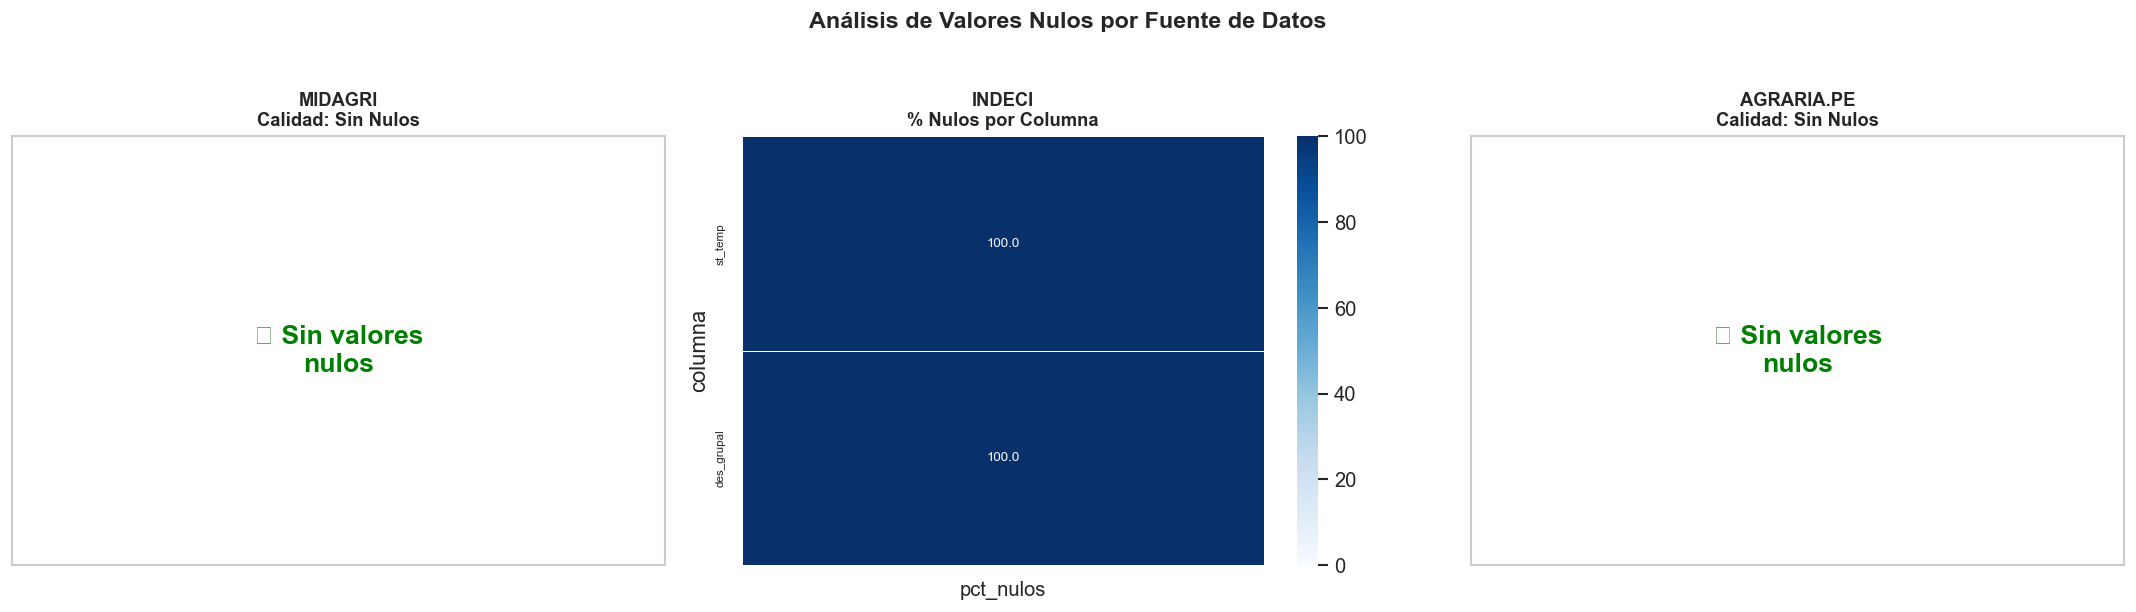

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fuentes = [(df_m.head(200), "MIDAGRI", 'YlGn'), (df_ev.head(200), "INDECI", 'Blues'), (df_n, "AGRARIA.PE", 'Oranges')]
for ax, (df, name, cmap) in zip(axes, fuentes):
    null_pct = (df.isnull().mean() * 100).reset_index()
    null_pct.columns = ['columna','pct_nulos']
    null_pct = null_pct[null_pct['pct_nulos'] > 0].sort_values('pct_nulos', ascending=False).head(20)
    if len(null_pct) > 0:
        pivot = null_pct.set_index('columna')[['pct_nulos']]
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True,
                    linewidths=0.5, vmin=0, vmax=100, annot_kws={'size':8})
        ax.set_title(f'{name}\n% Nulos por Columna', fontsize=11, fontweight='bold')
        ax.set_xlabel(''); ax.tick_params(axis='y', labelsize=7)
    else:
        ax.text(0.5, 0.5, '✅ Sin valores\nnulos', ha='center', va='center',
                fontsize=16, color='green', fontweight='bold', transform=ax.transAxes)
        ax.set_title(f'{name}\nCalidad: Sin Nulos', fontsize=11, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Análisis de Valores Nulos por Fuente de Datos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORTS}/g05_calidad_nulos.png", dpi=150, bbox_inches='tight')
plt.show()


## 4.2 Antes vs Después — Comparativa de Estandarización

In [4]:

print("=== ANTES de la estandarización (MIDAGRI) ===")
antes = df_m[['Dpto','Prov','dsc_Cultivo']].head(8)
display(antes)

def norm(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U')]: t=t.replace(a,b)
    return ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')

despues = antes.copy()
for c in ['Dpto','Prov','dsc_Cultivo']: despues[c] = despues[c].apply(norm)
print("\n=== DESPUÉS de la estandarización ===")
display(despues)


=== ANTES de la estandarización (MIDAGRI) ===


,Dpto,Prov,dsc_Cultivo
0,AMAZONAS,CHACHAPOYAS,LIMON
1,AMAZONAS,CHACHAPOYAS,LIMON
2,AMAZONAS,BAGUA,LIMON
3,AMAZONAS,BAGUA,LIMON
4,AMAZONAS,BAGUA,LIMON DULCE
5,AMAZONAS,BAGUA,LIMON
6,AMAZONAS,BAGUA,LIMON
7,AMAZONAS,LUYA,LIMON



=== DESPUÉS de la estandarización ===


,Dpto,Prov,dsc_Cultivo
0,AMAZONAS,CHACHAPOYAS,LIMON
1,AMAZONAS,CHACHAPOYAS,LIMON
2,AMAZONAS,BAGUA,LIMON
3,AMAZONAS,BAGUA,LIMON
4,AMAZONAS,BAGUA,LIMON DULCE
5,AMAZONAS,BAGUA,LIMON
6,AMAZONAS,BAGUA,LIMON
7,AMAZONAS,LUYA,LIMON


## 4.3 Outliers — Producción MIDAGRI

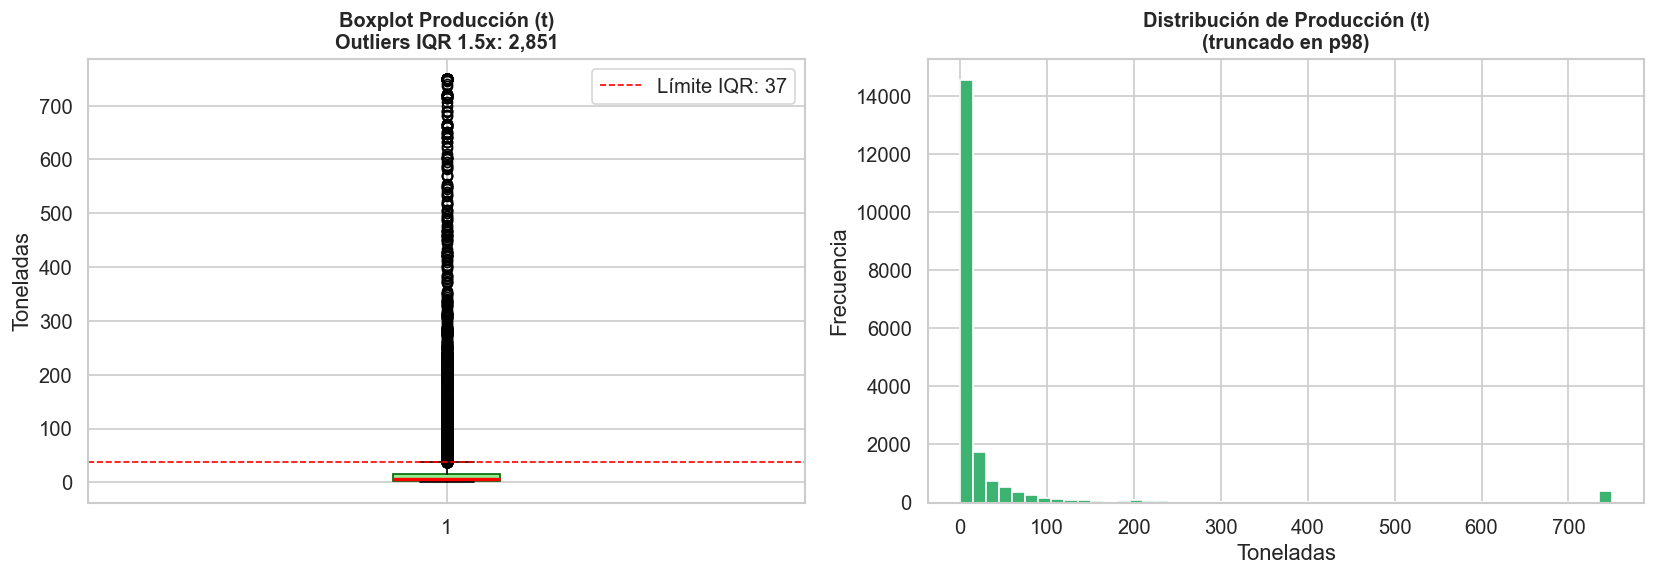

Outliers detectados: 2,851 (14.6%)


In [5]:

prod = pd.to_numeric(df_m['PRODUCCION(t)'], errors='coerce').dropna()
q1, q3 = prod.quantile(0.25), prod.quantile(0.75)
iqr = q3-q1; upper = q3+1.5*iqr
outliers_n = ((prod < q1-1.5*iqr) | (prod > upper)).sum()
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].boxplot(prod.clip(upper=prod.quantile(0.98)), patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[0].axhline(upper, color='red', linestyle='--', linewidth=1, label=f'Límite IQR: {upper:.0f}')
axes[0].set_title(f'Boxplot Producción (t)\nOutliers IQR 1.5x: {outliers_n:,}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Toneladas'); axes[0].legend()
prod.clip(upper=prod.quantile(0.98)).hist(bins=50, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribución de Producción (t)\n(truncado en p98)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Toneladas'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g06_outliers.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Outliers detectados: {outliers_n:,} ({outliers_n/len(prod)*100:.1f}%)")


## 4.4 Resumen de Decisiones

In [6]:

resumen = pd.DataFrame({
    'Fuente': ['MIDAGRI', 'INDECI Eventos', 'AGRARIA.PE'],
    'Filas': [len(df_m), len(df_ev), len(df_n)],
    'Cols con Nulos': [(df_m.isnull().sum()>0).sum(), (df_ev.isnull().sum()>0).sum(), (df_n.isnull().sum()>0).sum()],
    'Duplicados': [df_m.duplicated().sum(), df_ev.duplicated(subset=['ide_sinpad'] if 'ide_sinpad' in df_ev.columns else None).sum(), df_n.duplicated(subset=['url'] if 'url' in df_n.columns else None).sum()],
    'Acción': ['Renombrar + normalizar geo', 'Filtrar hidrometeorológicos + normalizar geo', 'Limpiar HTML/URLs con Regex']
})
display(resumen)
print("\n✅ [ACTIVIDAD 04] COMPLETADA")


,Fuente,Filas,Cols con Nulos,Duplicados,Acción
0,MIDAGRI,19573,0,0,Renombrar + normalizar geo
1,INDECI Eventos,25025,7,0,Filtrar hidrometeorológicos + normalizar geo
2,AGRARIA.PE,528,0,0,Limpiar HTML/URLs con Regex



✅ [ACTIVIDAD 04] COMPLETADA


## TODO: INTEGRACIÓN DATA NASA (COMPAÑERO)
```python
df_nasa = pd.read_csv(f"{INTERIM}/nasa_clima_raw.csv")
print("NASA nulos:\n", df_nasa.isnull().sum())
# Validar rangos físicos
invalidos = {'T2M fuera [-10,45]°C': ((df_nasa['T2M']<-10)|(df_nasa['T2M']>45)).sum(),
             'PRECTOTCORR negativo': (df_nasa['PRECTOTCORR']<0).sum(),
             'RH2M fuera [0,100]%': ((df_nasa['RH2M']<0)|(df_nasa['RH2M']>100)).sum()}
pd.Series(invalidos).plot(kind='bar', title='Registros NASA fuera de rango físico')
```